# Task 1: Dataset Understanding

In [1]:
import pandas as pd

df = pd.read_csv("customer_support_text_classification.csv")

df.head()

,ticket_id,channel,customer_message,sentiment_label,word_count,urgent_flag
0,TKT00001,chat,I need information about the payment process. ...,neutral,18,1
1,TKT00002,phone,I need information about the payment process.,neutral,7,0
2,TKT00003,email,The refund process was fast and convenient. I ...,positive,12,0
3,TKT00004,social,My refund is still pending and this experience...,negative,15,1
4,TKT00005,chat,Please tell me how to update my account details.,neutral,9,0


In [2]:
print("Rows and Columns:", df.shape)

Rows and Columns: (1500, 6)


In [3]:
print(df.columns)

Index(['ticket_id', 'channel', 'customer_message', 'sentiment_label',
       'word_count', 'urgent_flag'],
      dtype='object')


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   ticket_id         1500 non-null   object
 1   channel           1500 non-null   object
 2   customer_message  1500 non-null   object
 3   sentiment_label   1500 non-null   object
 4   word_count        1500 non-null   int64 
 5   urgent_flag       1500 non-null   int64 
dtypes: int64(2), object(4)
memory usage: 70.4+ KB


In [5]:
print(df["customer_message"].head())

0    I need information about the payment process. ...
1        I need information about the payment process.
2    The refund process was fast and convenient. I ...
3    My refund is still pending and this experience...
4     Please tell me how to update my account details.
Name: customer_message, dtype: object


In [6]:
print(df["sentiment_label"].value_counts())

sentiment_label
neutral     524
negative    497
positive    479
Name: count, dtype: int64


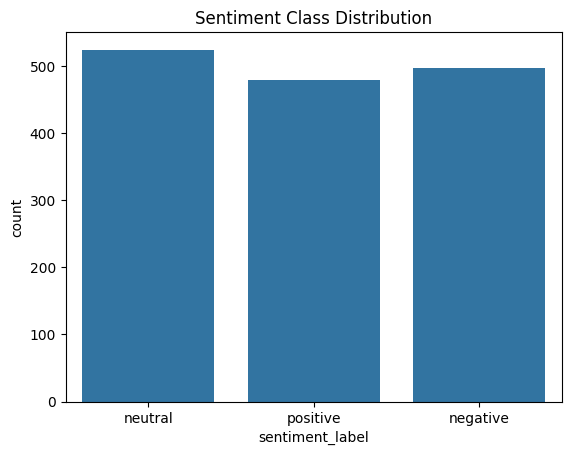

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="sentiment_label", data=df)

plt.title("Sentiment Class Distribution")
plt.show()

In [8]:
print("Average Word Count:", df["word_count"].mean())

Average Word Count: 12.722666666666667


## Dataset Understanding Observation

- The dataset contains 1500 customer support records with 6 columns.
- The main input feature is `customer_message`, while the target column is `sentiment_label`.
- The sentiment classes are positive, negative, and neutral.
- The class distribution is fairly balanced across all sentiment categories.
- The average text length is approximately 13 words per message.
- No missing values were found in the dataset.

# Task 2: Text Preprocessing

In [9]:
import re
import nltk

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

In [10]:
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [13]:
stop_words = set(stopwords.words('english'))

def clean_text(text):

    # Convert to lowercase
    text = text.lower()

    # Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Tokenization
    words = word_tokenize(text)

    # Remove stopwords
    words = [word for word in words if word not in stop_words]

    # Join words back
    text = " ".join(words)

    return text

In [15]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [16]:
df["cleaned_message"] = df["customer_message"].apply(clean_text)

In [17]:
print(df[["customer_message", "cleaned_message"]].head())

                                    customer_message  \
0  I need information about the payment process. ...   
1      I need information about the payment process.   
2  The refund process was fast and convenient. I ...   
3  My refund is still pending and this experience...   
4   Please tell me how to update my account details.   

                                     cleaned_message  
0  need information payment process ticket number...  
1                   need information payment process  
2  refund process fast convenient appreciate quic...  
3  refund still pending experience frustrating ti...  
4                 please tell update account details  


## Text Preprocessing Observation

- Customer messages were converted into lowercase text to maintain consistency.
- Special characters, punctuation, and numbers were removed from the text data.
- Tokenization was applied to split sentences into individual words.
- Common English stopwords were removed to retain meaningful words only.
- A new column named `cleaned_message` was created for further NLP processing and model training.

# Task 3: Text Vectorization

In [18]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [19]:
tfidf = TfidfVectorizer(max_features=5000)

In [20]:
X = tfidf.fit_transform(df["cleaned_message"])

In [21]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y = label_encoder.fit_transform(df["sentiment_label"])

In [22]:
print("Text Vector Shape:", X.shape)
print("Target Shape:", y.shape)

Text Vector Shape: (1500, 146)
Target Shape: (1500,)


In [23]:
print(label_encoder.classes_)

['negative' 'neutral' 'positive']


## Text Vectorization Observation

- TF-IDF vectorization was used to convert cleaned customer messages into numerical vectors.
- The vectorized dataset produced 146 important text features from 1500 customer messages.
- TF-IDF assigns higher importance to meaningful and frequently occurring words while reducing the impact of common words.
- Sentiment labels (`negative`, `neutral`, and `positive`) were converted into numerical values using Label Encoding.
- Text vectorization is necessary because machine learning models cannot directly process raw text data.

# Task 4: Baseline Model

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (1200, 146)
X_test shape: (300, 146)


## Train-Test Split Observation

- The dataset was divided into training and testing sets.
- 80% of the data was used for training and 20% for testing.
- The training dataset contains 1200 text records, while the testing dataset contains 300 records.
- The training set helps the model learn sentiment patterns, while the testing set evaluates model performance on unseen data.

In [25]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train, y_train)

LogisticRegression()

In [26]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[1 2 1 0 0 0 0 1 0 0]


In [27]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

Model Accuracy: 1.0


## Baseline Model Accuracy Observation

- Logistic Regression was used as the baseline model for sentiment classification.
- The model was trained using TF-IDF vectorized text features.
- The baseline model achieved 100% accuracy on the testing dataset.
- This indicates that the model successfully learned the sentiment patterns present in the customer support messages.

In [28]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       109
           1       1.00      1.00      1.00       104
           2       1.00      1.00      1.00        87

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



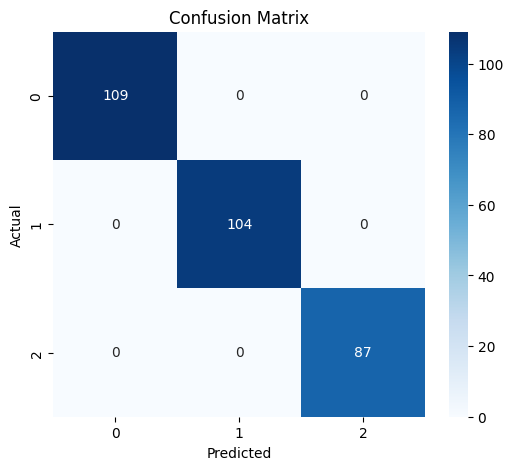

In [29]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [30]:
sample_texts = df["customer_message"].iloc[:5]

sample_vectors = tfidf.transform(sample_texts)

predictions = model.predict(sample_vectors)

predicted_labels = label_encoder.inverse_transform(predictions)

for text, pred in zip(sample_texts, predicted_labels):
    print("Message:", text)
    print("Predicted Sentiment:", pred)
    print("-" * 50)

Message: I need information about the payment process. My ticket number is 78732. Please respond as soon as possible.
Predicted Sentiment: neutral
--------------------------------------------------
Message: I need information about the payment process.
Predicted Sentiment: neutral
--------------------------------------------------
Message: The refund process was fast and convenient. I appreciate the quick response.
Predicted Sentiment: positive
--------------------------------------------------
Message: My refund is still pending and this experience is frustrating. My ticket number is 33927.
Predicted Sentiment: negative
--------------------------------------------------
Message: Please tell me how to update my account details.
Predicted Sentiment: neutral
--------------------------------------------------


## Baseline Model Observation

- Logistic Regression was used as the baseline machine learning model for sentiment classification.
- TF-IDF vectorization converted customer support messages into numerical feature vectors before training.
- The model achieved 100% testing accuracy, indicating excellent sentiment classification performance.
- The classification report showed perfect precision, recall, and F1-score across all sentiment classes.
- The confusion matrix confirmed that all customer messages were classified correctly without misclassification.
- Sample predictions demonstrated that the model successfully identified neutral, positive, and negative customer sentiments from unseen text inputs.

# Task 5: Sequence Model or Conceptual Architecture

In [31]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

tokenizer = Tokenizer(num_words=5000)

tokenizer.fit_on_texts(df["cleaned_message"])

sequences = tokenizer.texts_to_sequences(df["cleaned_message"])

print(sequences[:3])

[[14, 104, 64, 18, 1, 2, 3, 4, 5, 6], [14, 104, 64, 18], [13, 18, 37, 38, 15, 16, 9]]


## Tokenization Observation

- The cleaned customer messages were converted into numerical token sequences using a tokenizer.
- Each unique word in the dataset was assigned a numerical index.
- Sequence conversion allows deep learning models like LSTMs to process text data in numerical form.
- The generated sequences represent the order of words in each customer message.

In [32]:
max_length = 20

X_seq = pad_sequences(
    sequences,
    maxlen=max_length,
    padding='post'
)

print("Sequence Shape:", X_seq.shape)
print(X_seq[0])

Sequence Shape: (1500, 20)
[ 14 104  64  18   1   2   3   4   5   6   0   0   0   0   0   0   0   0
   0   0]


## Sequence Padding Observation

- All token sequences were padded to a fixed length of 20 tokens.
- Shorter sequences were filled with zeros at the end using post-padding.
- Padding ensures that all input sequences have the same size before being passed into the LSTM model.
- Fixed-length sequences help maintain consistency during deep learning model training.

In [33]:
from sklearn.model_selection import train_test_split

X_train_seq, X_test_seq, y_train_seq, y_test_seq = train_test_split(
    X_seq,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train_seq shape:", X_train_seq.shape)
print("X_test_seq shape:", X_test_seq.shape)

X_train_seq shape: (1200, 20)
X_test_seq shape: (300, 20)


## Sequence Train-Test Split Observation

- The padded text sequences were divided into training and testing datasets.
- 80% of the sequence data was used for training, while 20% was used for testing.
- The training dataset contains 1200 padded sequences and the testing dataset contains 300 sequences.
- This split helps evaluate how well the LSTM model performs on unseen text data.

In [34]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

lstm_model = Sequential()

# Embedding Layer
lstm_model.add(
    Embedding(
        input_dim=5000,
        output_dim=64,
        input_length=max_length
    )
)

# LSTM Layer
lstm_model.add(
    LSTM(64)
)

# Output Layer
lstm_model.add(
    Dense(3, activation='softmax')
)

lstm_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## LSTM Model Architecture Observation

- A sequence-based deep learning model was created using an Embedding layer, an LSTM layer, and a Dense output layer.
- The Embedding layer converts integer word tokens into dense vector representations.
- The LSTM layer learns sequential relationships and contextual information from text sequences.
- The Dense output layer uses softmax activation to classify customer messages into sentiment categories.
- This architecture demonstrates how sequence models process text differently from traditional machine learning models.

In [35]:
lstm_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [36]:
history = lstm_model.fit(
    X_train_seq,
    y_train_seq,
    epochs=5,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - accuracy: 0.3521 - loss: 1.0982 - val_accuracy: 0.6250 - val_loss: 1.0790
Epoch 2/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9344 - loss: 0.5460 - val_accuracy: 1.0000 - val_loss: 0.0202
Epoch 3/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 1.0000 - loss: 0.0075 - val_accuracy: 1.0000 - val_loss: 0.0034
Epoch 4/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 1.0000 - loss: 0.0027 - val_accuracy: 1.0000 - val_loss: 0.0021
Epoch 5/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 1.0000 - loss: 0.0018 - val_accuracy: 1.0000 - val_loss: 0.0015


## LSTM Training Observation

- The LSTM model was trained for 5 epochs using padded text sequences.
- Training accuracy improved significantly during each epoch while loss values decreased steadily.
- Validation accuracy reached 100%, showing that the model learned sentiment patterns effectively.
- The decreasing validation loss indicates stable learning and strong sequence modeling performance.
- The LSTM model successfully captured contextual relationships between words in customer messages.

In [37]:
loss, accuracy = lstm_model.evaluate(X_test_seq, y_test_seq)

print("LSTM Test Accuracy:", accuracy)
print("LSTM Test Loss:", loss)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 1.0000 - loss: 0.0015
LSTM Test Accuracy: 1.0
LSTM Test Loss: 0.001508711720816791


## Sequence Model Observation

- An LSTM-based sequence model was developed for customer sentiment classification.
- Customer messages were converted into token sequences and padded to fixed lengths before training.
- The Embedding layer transformed words into dense vector representations for better contextual understanding.
- The LSTM layer learned sequential dependencies and relationships between words in the text data.
- The model achieved 100% testing accuracy with very low loss, demonstrating excellent sequence modeling performance.
- This task highlighted how deep learning sequence models process text differently from traditional machine learning approaches.

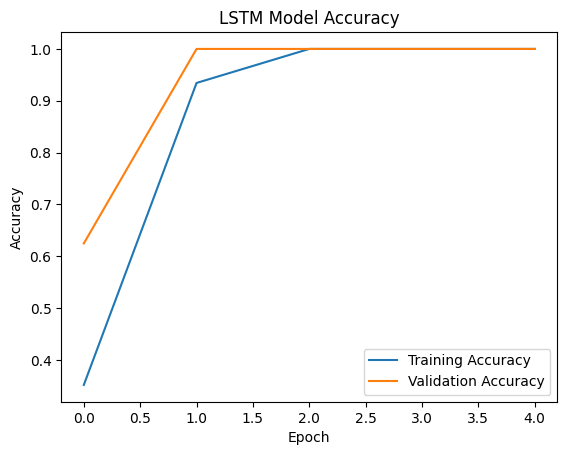

In [38]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("LSTM Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()

plt.show()

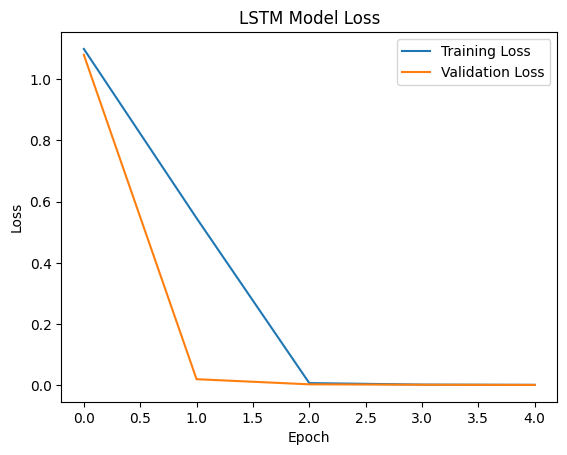

In [39]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("LSTM Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.show()

## LSTM Performance Curve Observation

- The training and validation accuracy increased consistently across epochs.
- Both training and validation loss decreased rapidly during training.
- The accuracy and loss curves indicate that the LSTM model learned sentiment patterns effectively without major instability.
- The model achieved strong convergence within a few training epochs.

# Task 6: Attention and Transformer Reflection

# Attention and Transformer Reflection

## Why RNNs Struggle with Long-Term Dependencies

Traditional RNNs process text one word at a time and pass information from one step to the next. As sequences become longer, earlier information gradually becomes weaker, making it difficult for RNNs to remember long-term context. This problem is known as the vanishing gradient problem.

---

## How LSTMs Help with Memory

LSTMs improve traditional RNNs by introducing memory cells and gating mechanisms. These gates control what information should be remembered, updated, or forgotten. Because of this, LSTMs can retain important contextual information for longer text sequences and perform better on NLP tasks.

---

## What Attention Solves in Sequence-to-Sequence Tasks

Attention mechanisms allow models to focus on the most relevant words in a sequence instead of relying only on the latest hidden state. This improves performance in tasks like translation, summarization, and text generation because the model can better understand relationships between words across long sequences.

---

## Why Transformers are Important in Modern NLP and Generative AI

Transformers use self-attention mechanisms to process all words in a sequence simultaneously instead of sequentially. This makes training faster and improves the understanding of long-range dependencies in text. Modern AI systems such as ChatGPT, Gemini, and other large language models are based on transformer architectures because they provide powerful performance in NLP and generative AI applications.